# Detection & Analysis of Pre-SN Outburst Simulations

[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys
import numpy as np
import pandas as pd

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, LightCurve, SimDetecLightCurve, SimDetecSupernova
from plot import Plot, PlotLimits
from utils import reformat_dir, get_config_flags
from generate_detec_table import ContaminationTable, Model, SimDetecTable, SimDetecTables, EfficiencyTable, AtlasSimDetecLoop

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading {PRESET} preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading atlas preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2019tfd'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = False
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/bump_analysis/plots'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 58759.131956

# Enter the size of the MJD bins (in days):
MJD_BIN_SIZE = 1.0

# Enter the number of control light curves to load:
NUM_CONTROLS = int(config["download"]["num_controls"])

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Output directory (load cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load cleaned light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(OUTPUT_DIR, NUM_CONTROLS, cleaned=True)

# load binned light curves
avg_sn = SimDetecSupernova(colnames, tnsname=TNSNAME, mjdbinsize=MJD_BIN_SIZE, mjd0=DISCOVERY_DATE, filt=FILT)
avg_sn.load_all(OUTPUT_DIR, NUM_CONTROLS)

p = Plot(PLOTS_DIR)

SN 2019tfd, filter o, discovery date: 58759.131956
Output directory (load cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019tfd
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019tfd/bump_analysis/plots

Loading SN light curve and 8 control light curves...
Successfully loaded SN light curve and 8 control light curves (control indices: [1, 2, 3, 4, 5, 6, 7, 8])
Updating column names for all light curves in this Supernova object (key: dflux_new, name: duJy_new)...

Loading averaged SN light curve and 8 averaged control light curves...
Successfully loaded averaged SN light curve and 8 averaged control light curves (control indices: [1, 2, 3, 4, 5, 6, 7, 8])


## Plot cleaned original and binned pre-SN light curves


Searching config file for custom cuts...
Found 1


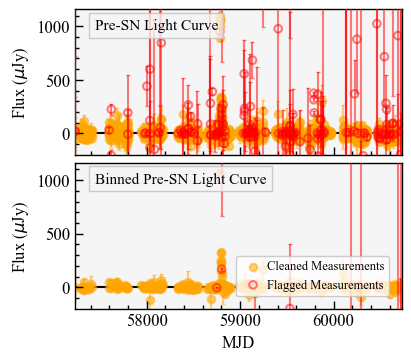

In [ ]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

flags = get_config_flags(config)

fig = p.plot_preSN(
    sn, 
    avg_sn, 
    flags,
    save=SAVE_PLOTS
)